In [1]:
import sys, os
sys.path.append(os.path.abspath("../"))

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from pynitride.mesh import Mesh, MaterialBlock, UniformLayer
from pynitride.material import Insulator, AlGaN
from pynitride.paramdb import nm, cm, eV
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP
from pynitride.solvers import SelfConsistentLoop, PoissonSolver, Equilibrium, Linear_Fermi

In [4]:
m=Mesh(
    [
        MaterialBlock(Insulator("SiO2"),[
            UniformLayer("diel",7*nm)
        ]),
        MaterialBlock(AlGaN(),[
            UniformLayer("well",5*nm),
            UniformLayer("subs",500*nm,x=1,DeepDonorDonorConc=5.0e16/cm**3)
        ])
    ],
    max_dz=10*nm,
    refinements=[["diel/well",.01*nm,5],
                 ["well/subs",.01*nm,1.6]],
    boundary=[2*eV,'thick']
)

(0, 30)

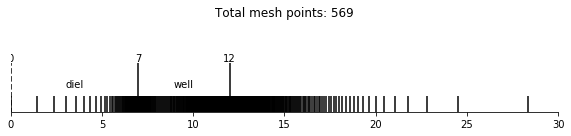

In [5]:
m.plot_mesh()
plt.xlim(0,30)

In [6]:
m.ensure_function_exists("p",value=0)
m.ensure_function_exists("n",value=0)
m.ensure_function_exists("pderiv",value=0)
m.ensure_function_exists("nderiv",value=0)
m.ensure_function_exists("fc",value=0)

In [7]:
m._functions.keys()

dict_keys(['p', 'n', 'pderiv', 'nderiv', 'fc'])

In [8]:
idw=m.interfaces_point[0][0]
m.fc[idw]=4.7e13/(1e7)**2/m.dzm[idw]

In [9]:
_,shm,scm=m.submesh_cover([8*nm,20*nm])

In [10]:
from pynitride.mesh import MidFunction

In [11]:
#Equilibrium(m)
Linear_Fermi(m,contacts={'gate':0,'idw':1,'source':2,'subs':3}).solve(**dict(gate=-5,idw=0,source=0,subs=0))
sc=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Schrodinger(shm),Semiclassical(scm)],)

In [12]:
sc.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.005)

Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Starting SC loop
    iter:   0  err: 1.63e-01  activ: 1
    iter:   1  err: 2.17e-02  activ: 1
    iter:   2  err: 3.10e-04  activ: 1
    iter:   3  err: 5.91e-08  activ: 1
    Loop finished in  4 iterations with err=5.91366e-08
  Eps factor: 6.31e+02
  Starting SC loop
    iter:   0  err: 4.70e-02  activ: 1
    iter:   1  err: 1.33e-03  activ: 1
    iter:   2  err: 7.61e-07  activ: 1
    Loop finished in  3 iterations with err=7.60568e-07
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 9.95e-02  activ: 1
    iter:   1  err: 2.81e-03  activ: 1
    iter:   2  err: 8.81e-06  activ: 1
    iter:   3  err: 1.07e-08  activ: 1
    Loop finished in  4 iterations with err=1.07131e-08
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 1.56e-01  activ: 1
    iter:   1  err: 8.58e-03  activ: 1
    iter:   2  err: 3.47e-04  activ: 1
    iter:   3  err: 7.73e-07  activ: 1
    Loop finished in  4 iterations with

In [13]:
psm=PoissonSolver(m)
psm.solve()
if 1:
    mbkp=MultibandKP(shm,ktmax=2.5,num_kpoints=30)
    # WHT IS THIS?
    for H in mbkp._H:
        H[:6,:6]*=2
        H[-6:,-6:]*=2
    scl=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[mbkp,Semiclassical(shm,'electron'),Semiclassical(scm)])
    scl.loop(tol=1e-8)

lcr
1046519.52283
-2093807.2273
1047288.57724
Assembling k.p matrices ...
Done assembly.
Starting SC loop
  iter:   0  err: 1.67e-01  activ: 1
  iter:   1  err: 8.13e-02  activ: 1
  iter:   2  err: 3.11e-02  activ: 1
  iter:   3  err: 8.73e-03  activ: 1
  iter:   4  err: 6.04e-04  activ: 1
  iter:   5  err: 1.78e-05  activ: 1
  iter:   6  err: 5.15e-06  activ: 1
  iter:   7  err: 1.48e-06  activ: 1
  iter:   8  err: 4.30e-07  activ: 1
  iter:   9  err: 1.25e-07  activ: 1
  iter:  10  err: 3.64e-08  activ: 1
  iter:  11  err: 1.06e-08  activ: 1
  iter:  12  err: 3.08e-09  activ: 1
  Loop finished in 13 iterations with err=3.08448e-09


1.6995388980735076


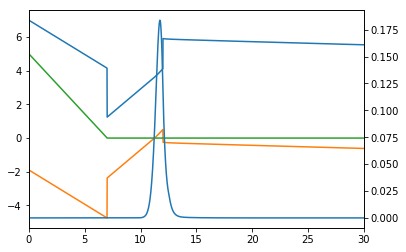

In [14]:
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)
plt.xlim(0,30)
plt.twinx()
plt.plot(m.zp,m.p)
print(m.p.integrate(definite=True)/(1/cm**2)/1e13)